<a href="https://colab.research.google.com/github/heoconngoc/Deep_Learning/blob/main/12_Optimization_Algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

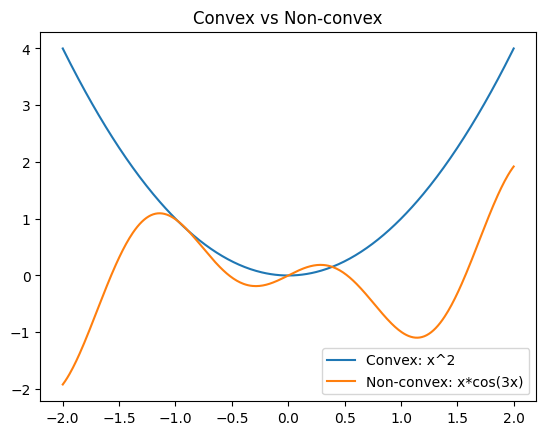

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 1. Convex vs Non-convex
# =========================================
x = np.linspace(-2, 2, 400)
convex = x**2
nonconvex = x * np.cos(3*x)

plt.figure()
plt.plot(x, convex, label='Convex: x^2')
plt.plot(x, nonconvex, label='Non-convex: x*cos(3x)')
plt.title('Convex vs Non-convex')
plt.legend()
plt.show()

# Convex has 1 minimum → easy to optimize
# Non-convex có nhiều local minima → khó

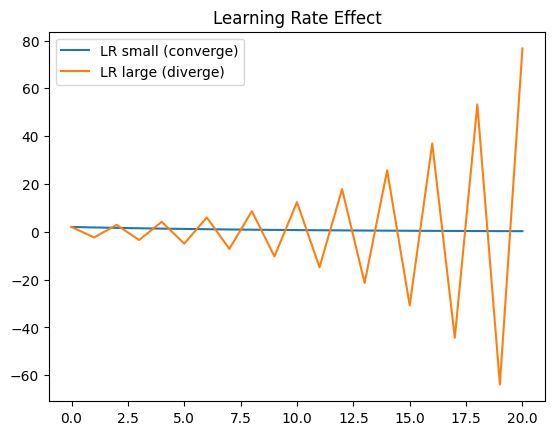

In [2]:
# =========================================
# 2. Learning rate effect
# =========================================
def gd_path(lr):
    x = 2.0
    path = [x]
    for _ in range(20):
        grad = 2*x
        x = x - lr*grad
        path.append(x)
    return path

path_small = gd_path(0.05)
path_big = gd_path(1.1)

plt.figure()
plt.plot(path_small, label='LR small (converge)')
plt.plot(path_big, label='LR large (diverge)')
plt.title('Learning Rate Effect')
plt.legend()
plt.show()

# 👉 Ý nghĩa:
# small LR → slowly learn
# big LR → diverge


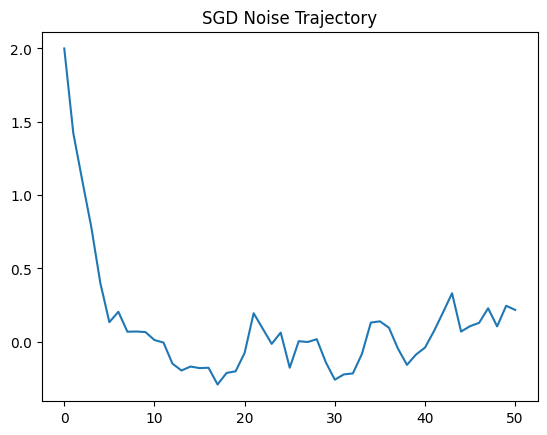

In [3]:
# =========================================
# 3. SGD noise
# =========================================
np.random.seed(0)
x = 2.0
path = [x]

for _ in range(50):
    grad = 2*x + np.random.normal(0, 1)  # noise
    x = x - 0.1*grad
    path.append(x)

plt.figure()
plt.plot(path)
plt.title('SGD Noise Trajectory')
plt.show()

# SGD goes zig-zag as it has noise
# Noise helps SGD escaping local minima

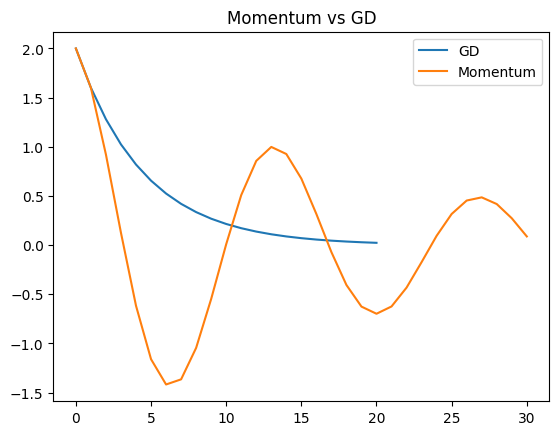

In [4]:
# =========================================
# 4. Momentum vs GD
# =========================================
def momentum_path(lr=0.1, beta=0.9):
    x = 2.0
    v = 0
    path = [x]
    for _ in range(30):
        grad = 2*x
        v = beta*v + grad
        x = x - lr*v
        path.append(x)
    return path

path_gd = gd_path(0.1)
path_mom = momentum_path()

plt.figure()
plt.plot(path_gd[:30], label='GD')
plt.plot(path_mom, label='Momentum')
plt.legend()
plt.title('Momentum vs GD')
plt.show()

# Momentum smoother + quicker than GD

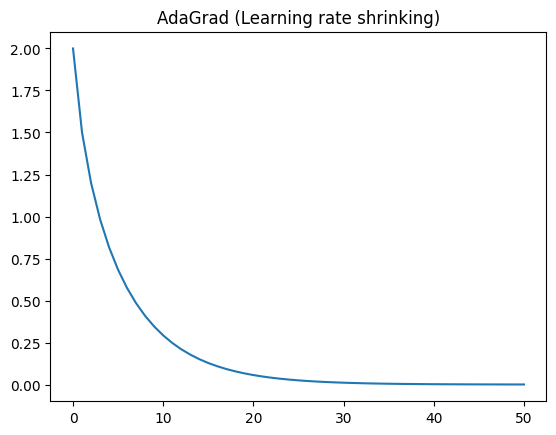

In [5]:
# =========================================
# 5. AdaGrad
# =========================================
def adagrad_path():
    x = 2.0
    s = 0
    path = [x]

    for _ in range(50):
        grad = 2*x
        s += grad**2
        x = x - 0.5 * grad / np.sqrt(s + 1e-6)
        path.append(x)

    return path

plt.figure()
plt.plot(adagrad_path())
plt.title('AdaGrad (Learning rate shrinking)')
plt.show()


# smaller step → finally nearly stay

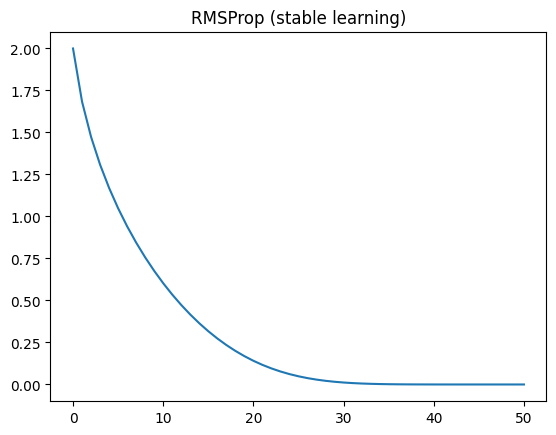

In [6]:
# =========================================
# 6. RMSProp
# =========================================
def rmsprop_path():
    x = 2.0
    s = 0
    gamma = 0.9
    path = [x]

    for _ in range(50):
        grad = 2*x
        s = gamma*s + (1-gamma)*grad**2
        x = x - 0.1 * grad / np.sqrt(s + 1e-6)
        path.append(x)

    return path

plt.figure()
plt.plot(rmsprop_path())
plt.title('RMSProp (stable learning)')
plt.show()

# leaky average, no decay problem like Adagrad

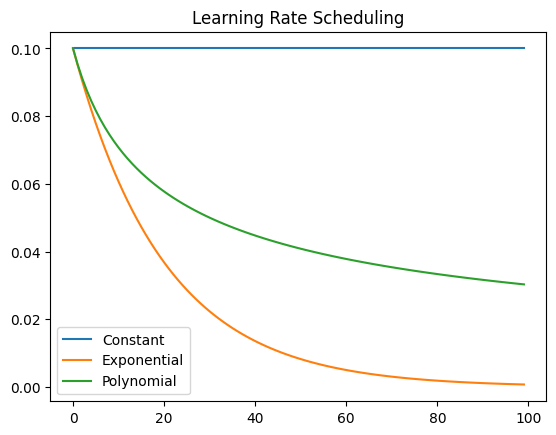

In [7]:
# =========================================
# 7. Learning rate schedules
# =========================================
steps = np.arange(100)

const = np.ones_like(steps) * 0.1
exp = 0.1 * np.exp(-0.05 * steps)
poly = 0.1 / np.sqrt(1 + 0.1 * steps)

plt.figure()
plt.plot(steps, const, label='Constant')
plt.plot(steps, exp, label='Exponential')
plt.plot(steps, poly, label='Polynomial')
plt.legend()
plt.title('Learning Rate Scheduling')
plt.show()

# Constant → easy overfit
# Exponential → decrease to quickly
# Polynomial → stabilize